# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print("Current working directory:", os.getcwd())
print("Contents of the current directory:")
for item in os.listdir('.'):
    print(f"  {item}")

# 2. Acquire and load your primary dataset
# Move our working spot up to the project root so paths like "data/hw/..." work
project_root = os.getcwd().split('/notebooks')[0]
os.chdir(project_root)
print("Working from:", os.getcwd())
# Load the primary dataset: democracy + GDP indicators
democracy_gdp = pd.read_csv('data/hw/democracy_gdp.csv')
democracy_gdp.head()

Current working directory: /Users/dmk/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3
Contents of the current directory:
  .DS_Store
  hw_3_Dongman_kim.ipynb
Working from: /Users/dmk/Documents/GitHub/datascience-publicpolicy-2026


,country,year,v2x_frassoc_thick,NGDPDPC,NGDP_RPCH,v2x_pubcorr,v2xnp_regcorr,v2xel_frefair,v2x_freexp,v2elembcap
0,AFG,1990,0.063,NaN,NaN,0.556,0.538,0.069,0.085,-1.65
1,AFG,1991,0.068,NaN,NaN,0.556,0.538,0.069,0.074,-1.65
2,AFG,1992,0.134,NaN,NaN,0.645,0.736,0.028,0.071,-1.65
3,AFG,1993,0.159,NaN,NaN,0.843,0.909,0.000,0.069,-1.65
4,AFG,1994,0.159,NaN,NaN,0.843,0.909,0.000,0.069,-1.65


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- Source: V-Dem (democracy indicators) + IMF (GDP per capita), provided as democracy_gdp.csv in the course repo.

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
democracy_gdp.info()
democracy_gdp.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5600 entries, 0 to 5599
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            5600 non-null   object 
 1   year               5600 non-null   int64  
 2   v2x_frassoc_thick  5600 non-null   float64
 3   NGDPDPC            4515 non-null   float64
 4   NGDP_RPCH          4515 non-null   float64
 5   v2x_pubcorr        5589 non-null   float64
 6   v2xnp_regcorr      5589 non-null   float64
 7   v2xel_frefair      5600 non-null   float64
 8   v2x_freexp         5600 non-null   float64
 9   v2elembcap         5600 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 437.6+ KB


,country,year,v2x_frassoc_thick,NGDPDPC,NGDP_RPCH,v2x_pubcorr,v2xnp_regcorr,v2xel_frefair,v2x_freexp,v2elembcap
0,AFG,1990,0.063,NaN,NaN,0.556,0.538,0.069,0.085,-1.65
1,AFG,1991,0.068,NaN,NaN,0.556,0.538,0.069,0.074,-1.65
2,AFG,1992,0.134,NaN,NaN,0.645,0.736,0.028,0.071,-1.65
3,AFG,1993,0.159,NaN,NaN,0.843,0.909,0.000,0.069,-1.65
4,AFG,1994,0.159,NaN,NaN,0.843,0.909,0.000,0.069,-1.65


In [3]:
# 2. Rename columns and select a clean subset
#  A dictionary maps OLD column name -> NEW clean name
column_map = {
    'country': 'country',
    'year': 'year',
    'v2x_frassoc_thick': 'democracy_index'
}
democracy_clean = democracy_gdp[list(column_map.keys())].rename(columns=column_map)
democracy_clean.head()

,country,year,democracy_index
0,AFG,1990,0.063
1,AFG,1991,0.068
2,AFG,1992,0.134
3,AFG,1993,0.159
4,AFG,1994,0.159


In [4]:
# 3. Filter row or column filters if necessary
democracy_clean = democracy_clean.query("country != 'Asia (avg)'")
democracy_clean['country'].unique()

array(['AFG', 'ARM', 'AZE', 'BGD', 'BTN', 'CHN', 'GEO', 'HKG', 'IDN',
       'IND', 'JPN', 'KAZ', 'KGZ', 'KHM', 'KOR', 'LAO', 'LKA', 'MDV',
       'MMR', 'MNG', 'MYS', 'NPL', 'PAK', 'PHL', 'PRK', 'SGP', 'THA',
       'TJK', 'TKM', 'TLS', 'TWN', 'UZB', 'VNM'], dtype=object)

In [5]:
# 4. Handle missing values (NaNs) if necessary
democracy_clean = democracy_clean.dropna()
democracy_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5565 entries, 0 to 5599
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          5565 non-null   object 
 1   year             5565 non-null   int64  
 2   democracy_index  5565 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 173.9+ KB


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
ghg = pd.read_csv('data/hw/ghg.csv')
# Rename "Country" to "country_name"
ghg = ghg.rename(columns={'Country': 'country_name'})
ghg.head()

,country_name,year,emissions
0,Aruba,1970,0.036713
1,Aruba,1971,0.041538
2,Aruba,1972,0.052391
3,Aruba,1973,0.057360
4,Aruba,1974,0.056630


In [7]:
# 2. Merge your datasets on a common key
code_to_name = {
    'AFG': 'Afghanistan', 'ARM': 'Armenia', 'AZE': 'Azerbaijan', 'BGD': 'Bangladesh',
    'BTN': 'Bhutan', 'CHN': 'China', 'GEO': 'Georgia', 'HKG': 'Hong Kong',
    'IDN': 'Indonesia', 'IND': 'India', 'JPN': 'Japan', 'KAZ': 'Kazakhstan',
    'KGZ': 'Kyrgyzstan', 'KHM': 'Cambodia', 'KOR': 'South Korea', 'LAO': 'Laos',
    'LKA': 'Sri Lanka', 'MDV': 'Maldives', 'MMR': 'Myanmar/Burma', 'MNG': 'Mongolia',
    'MYS': 'Malaysia', 'NPL': 'Nepal', 'PAK': 'Pakistan', 'PHL': 'Philippines',
    'PRK': 'North Korea', 'SGP': 'Singapore', 'THA': 'Thailand', 'TJK': 'Tajikistan',
    'TKM': 'Turkmenistan', 'TLS': 'Timor-Leste', 'TWN': 'Taiwan', 'UZB': 'Uzbekistan',
    'VNM': 'Viet Nam'
}
democracy_clean['country_name'] = democracy_clean['country'].map(code_to_name)
# The source data has duplicate rows — collapse identical rows to one
democracy_clean = democracy_clean.drop_duplicates()
merged = democracy_clean.merge(ghg, on=['country_name', 'year'], how='inner')
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (1122, 5)


,country,year,democracy_index,country_name,emissions
0,AFG,1990,0.063,Afghanistan,12.561600
1,AFG,1991,0.068,Afghanistan,12.623402
2,AFG,1992,0.134,Afghanistan,11.644234
3,AFG,1993,0.159,Afghanistan,11.745771
4,AFG,1994,0.159,Afghanistan,11.768691


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- **Merge key:** country name + year
- **Observations retained:** 1,122 matched country-year rows across 33 Asian countries (1990–2023).

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# Bin the continuous democracy_index into Low / Medium / High groups
merged['democracy_level'] = pd.cut(
    merged['democracy_index'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

# For each democracy level, summarize emissions
emissions_by_level = merged.groupby('democracy_level')['emissions'].agg(['mean', 'median', 'count'])
emissions_by_level

/var/folders/gz/qvx5j1p51y57yzh4xgmnqb5c0000gn/T/ipykernel_40029/2485057763.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emissions_by_level = merged.groupby('democracy_level')['emissions'].agg(['mean', 'median', 'count'])


,mean,median,count
democracy_level,,,
Low,971.762232,94.993326,362
Medium,114.524614,42.460562,173
High,371.709555,121.139507,587


- It looks like low-democracy countries pollute the most (average 972), but their median is only 95 — so a few huge emitters like China are pulling the average up. By median, high-democracy countries actually emit the most. But since these are total emissions, the results mostly reflect country size, not democracy.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

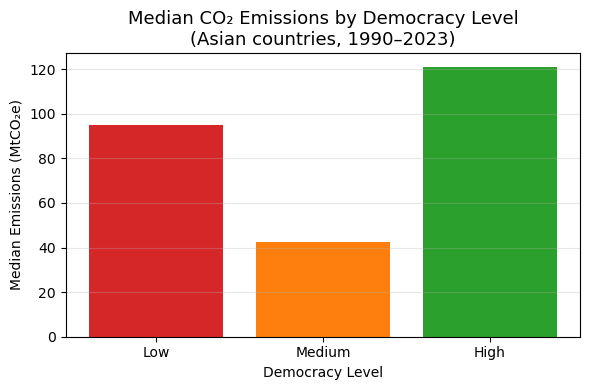

In [9]:
# Plot 1: Median emissions by democracy level
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(emissions_by_level.index.astype(str), emissions_by_level['median'],
       color=['#d62728', '#ff7f0e', '#2ca02c'])

ax.set_title('Median CO₂ Emissions by Democracy Level\n(Asian countries, 1990–2023)', fontsize=13)
ax.set_xlabel('Democracy Level')
ax.set_ylabel('Median Emissions (MtCO₂e)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

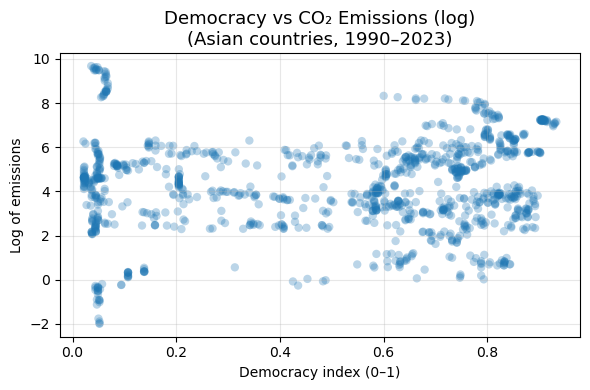

In [10]:
# Plot 2: democracy vs (log) emissions
import numpy as np

# emissions span a huge range, so take the log for a readable scatter
merged['log_emissions'] = np.log(merged['emissions'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(merged['democracy_index'], merged['log_emissions'],
           alpha=0.3, color='#1f77b4', edgecolor='none')

ax.set_title('Democracy vs CO₂ Emissions (log)\n(Asian countries, 1990–2023)', fontsize=13)
ax.set_xlabel('Democracy index (0–1)')
ax.set_ylabel('Log of emissions')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:          log_emissions   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     8.923
Date:                Fri, 19 Jun 2026   Prob (F-statistic):            0.00288
Time:                        18:53:22   Log-Likelihood:                -2390.3
No. Observations:                1122   AIC:                             4785.
Df Residuals:                    1120   BIC:                             4795.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.9973      0.117     

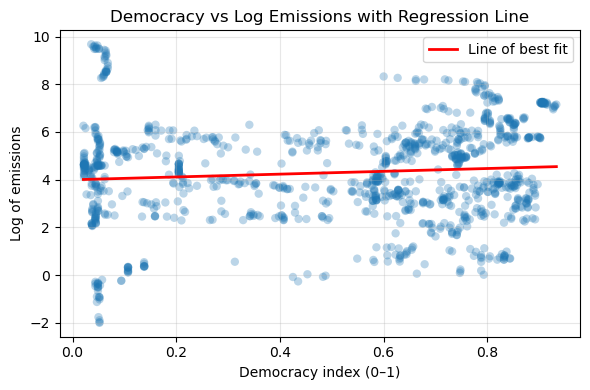

In [11]:
# Fit a simple linear regression and overlay the line of best fit
import statsmodels.api as sm

# Model: log_emissions explained by democracy_index (a "Log-Level" model)
X = sm.add_constant(merged['democracy_index'])   # predictor + an intercept
y = merged['log_emissions']                       # outcome
model = sm.OLS(y, X).fit()
print(model.summary())

# Re-draw the scatter with the regression line on top
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(merged['democracy_index'], merged['log_emissions'],
           alpha=0.3, color='#1f77b4', edgecolor='none')

x_line = np.linspace(merged['democracy_index'].min(), merged['democracy_index'].max(), 100)
y_line = model.params['const'] + model.params['democracy_index'] * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label='Line of best fit')

ax.set_title('Democracy vs Log Emissions with Regression Line', fontsize=12)
ax.set_xlabel('Democracy index (0–1)')
ax.set_ylabel('Log of emissions')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- The regression shows a small positive link: the democracy slope is 0.59 and statistically significant (p = 0.003), so more democratic Asian countries emit slightly more. But the R-squared is only 0.008 — democracy explains less than 1% of the differences in emissions. So the relationship is real but very weak, and the red line is almost flat. Emissions seem to be driven by other things (like country size), not democracy.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.